In [1]:
import numpy as np
import matplotlib.pyplot as plt
from episbi.models import Transition, compartment_model

In [2]:
compartments = ["S", "E", "I", "R"]
transitions = [
    Transition("S", "E", "beta * S * I / N", name="S_to_E"),
    Transition("E", "I", "kappa * E", name="E_to_I"),
    Transition("I", "R", "gamma * I", name="I_to_R"),
]
param_names = ["beta", "kappa", "gamma"]

In [3]:
N = 100_000
E0 = 0
I0 = 10
R0 = 0
S0 = N - E0 - I0 - R0

total_days = 100
initial_conditions = {"S": S0, "E": E0, "I": I0, "R": R0}
theta = {"beta": 0.80, "kappa": 0.30, "gamma": 0.35}

In [4]:
det_seir_model = compartment_model(
    compartments=compartments,
    transitions=transitions,
    param_names=param_names,
    model_type="deterministic",
    initial_conditions=initial_conditions,
    observed={"compartments": ["S","E","I","R"]}
)

In [5]:
print(det_seir_model.show())

Model type: deterministic
Compartments: S, E, I, R
Parameters: beta, kappa, gamma
Transitions:
  S_to_E: S -> E, rate=beta * S * I / N
  E_to_I: E -> I, rate=kappa * E
  I_to_R: I -> R, rate=gamma * I
Observed:
  S
  E
  I
  R


In [6]:
result = det_seir_model(theta,total_days= total_days)

result.keys()

dict_keys(['S', 'E', 'I', 'R'])

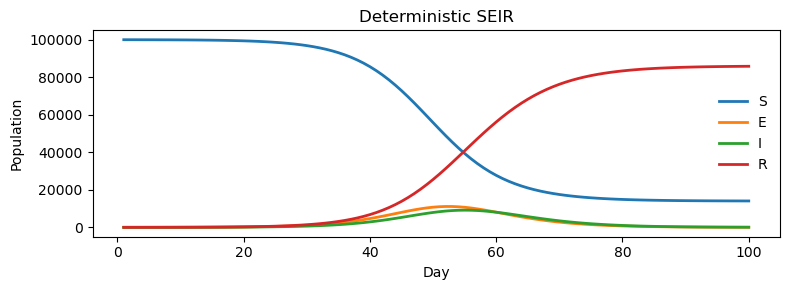

In [7]:
days = np.arange(1, len(result["S"]) + 1)
fig, ax = plt.subplots(figsize=(8, 3))

for name in ["S", "E", "I", "R"]:
    ax.plot(days, result[name], linewidth=2, label=name)

ax.set_xlabel("Day")
ax.set_ylabel("Population")
ax.set_title("Deterministic SEIR")
ax.legend(frameon=False)
fig.tight_layout()

In [8]:
det_i_to_r_model = compartment_model(
    compartments=compartments,
    transitions=transitions,
    param_names=param_names,
    model_type="deterministic",
    initial_conditions=initial_conditions,
    observed={"transitions": ["E_to_I"]},
)

In [9]:
i_to_r_clean = det_i_to_r_model(
    theta,
    total_days=total_days,
)

i_to_r_noisy = det_i_to_r_model(
    theta,
    total_days=total_days,
    observation_error="poisson",
    seed=1,
)

i_to_r_noisy.keys()

dict_keys(['E_to_I'])

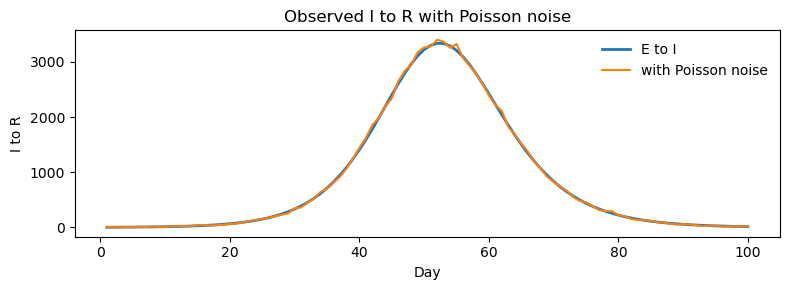

In [10]:
days = np.arange(1, total_days + 1)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(days, i_to_r_clean["E_to_I"], linewidth=2, label="E to I")
ax.plot(days, i_to_r_noisy["E_to_I"], label="with Poisson noise")
ax.set_xlabel("Day")
ax.set_ylabel("I to R")
ax.set_title("Observed I to R with Poisson noise")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()